# Initial Setup and Data Preparation:

## Setting up environment

Introduce the dependency so that the user can setup in advance

In [ ]:
!git clone https://github.com/Kangningthu/DeepDenoisingGuide

## Setting the file root folder path

In [ ]:
import os
import sys

file_root_path = '/content/DeepDenoisingGuide'
sys.path.append(file_root_path)
path_to_image_data = file_root_path + '/electron-microscopy-denoising/dataset/5'
path_to_saved_models = file_root_path + '/pretrain_models/Microscopy/'
if not os.path.exists(path_to_saved_models):
    os.makedirs(path_to_saved_models)


In [ ]:
!export file_root_path=/content/DeepDenoisingGuide

In [ ]:
import os

from PIL import Image

import numpy as np
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt

import cv2
# from skimage.measure.simple_metrics import compare_psnr
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
import glob
import pickle

import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import argparse
import sys
import torchvision
import torch
from torch.serialization import default_restore_location
from torch.distributions import Poisson
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
sys.path.append(file_root_path+'/electron-microscopy-denoising')
import data
import models
import utils
import sys

In [ ]:
device = torch.device('cpu')

In [ ]:
noise_scale = 2

In [ ]:
kernel_size = 2
# noise_std_array = [float(10)/255, float(25)/255, float(55)/255];

n_examples = 3 #number of examples to plot

### Download and organize Dataset

In [ ]:
!pip install gdown
!gdown --id 1UAddUxkP0I7GEvKRDzK0scLA6IERN15T

In [ ]:
!unzip images.zip -d $file_root_path/electron-microscopy-denoising

In [ ]:
! mkdir $file_root_path/electron-microscopy-denoising/images/images
! mv $file_root_path/electron-microscopy-denoising/images/5 $file_root_path/electron-microscopy-denoising/images/images/5

In [ ]:
# !unzip images.zip -d /content/DeepDenoisingGuide/electron-microscopy-denoising
# ! mkdir /content/DeepDenoisingGuide/electron-microscopy-denoising/images/images
# ! mv /content/DeepDenoisingGuide/electron-microscopy-denoising/images/5 /content/DeepDenoisingGuide/electron-microscopy-denoising/images/images/

## Creating Dataloader

n_val random images are set for validation while rest of the images are in training

In [ ]:
n_val = 25;
files_source = glob.glob(os.path.join(path_to_image_data, '*.tif'))
files_source = np.sort(files_source)
list_val_images = files_source[-n_val:]
list_train_images = list( set(files_source) - set(list_val_images));

In [ ]:
import torch
import numpy as np
from PIL import Image
from torchvision import transforms

class Dataset(torch.utils.data.Dataset):
    def __init__(self, list_of_image_path):
        super(Dataset, self).__init__()

        self.n_data = len(list_of_image_path)
        self.data_list = [None] * self.n_data

        # Random cropping transform, crop size can be changed
        self.transform = transforms.RandomCrop(224)

        for i in range(self.n_data):
            f = list_of_image_path[i]
            Img = np.array(Image.open(f))  # Directly read the image without resizing
            self.data_list[i] = Img

    def __len__(self):
        return self.n_data

    def __getitem__(self, index):
        data = self.data_list[index]
        data = Image.fromarray(data.astype('uint8'))  # Convert np.array to PIL Image for applying transform
        data = self.transform(data)  # Apply random cropping
        data = np.array(data)  # Convert back to np.array
        return torch.Tensor(data).permute(2, 0, 1).float()  # Change dimensions to CxHxW and convert to float

    def normalize(self, data):
        return data / 255.

# Example usage:
# list_of_image_path = ["image1.jpg", "image2.jpg"]  # Replace with actual image paths
# dataset = Dataset(list_of_image_path)


In [ ]:
# dataset = 'ptceo2'
# dataset = 'ptceo2_resized'
dataset = 'ptceo2'
contrast = 'white'
data_path = file_root_path + '/electron-microscopy-denoising/images'
batch_size = 1

USE_CUDA = True
device = torch.device("cuda") if (
        torch.cuda.is_available() and USE_CUDA) else torch.device("cpu")

In [ ]:
train_loader, val_loader, test_loader = data.build_dataset(dataset, data_path,
                                           test_batch_size=batch_size, rotation_aug = False, resize_aug=False,
                                           contrast = contrast, num_workers=0,image_size=256)

In [ ]:
train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset

In [ ]:
train_dataset[1]['image'].size()

torch.Size([1, 256, 256])

In [ ]:
len(train_dataset)

353

In [ ]:
len(val_dataset)

19

In [ ]:
len(test_dataset)

22

## Visualizing utils

In [ ]:
def batch_PSNR(img, imclean, data_range):
    Img = img.data.cpu().numpy().astype(np.float32)
    Iclean = imclean.data.cpu().numpy().astype(np.float32)
    PSNR = 0
    for i in range(Img.shape[0]):
        PSNR += compare_psnr(Iclean[i,:,:,:], Img[i,:,:,:], data_range=data_range)
    return (PSNR/Img.shape[0])

In [ ]:
def normalize(data):
    return data/255.

def get_test_image(path_to_dataset, index):
    files_source = glob.glob(os.path.join(path_to_dataset, '*.png'))
    files_source.sort()

    f = files_source[index];

    Img = cv2.imread(f)
    Img = normalize(np.float32(Img[:,:,0]))
    Img = np.expand_dims(Img, 0)
    Img = np.expand_dims(Img, 1)
    ISource = torch.Tensor(Img).to(device)

    return ISource


In [ ]:
from torch.distributions import Poisson

In [ ]:
def get_noise(data, noise_std = 0.1, mode='poisson', max_noise = 5e-1, noise_scale=50):
    if mode=='poisson':
        source = data
        scaled_source = source * noise_scale
        # Generate Poisson noise sample based on the scaled source
        noise_sample = Poisson(scaled_source).sample()
        # Scale back the generated noise
        noise_sample = (noise_sample - scaled_source) / noise_scale
        noise = noise_sample
    else:
        noise = get_noise_others(data, noise_std, mode, max_noise)
    return noise

def get_noise_others(data, noise_std = 0.1, mode='S', max_noise = 5e-1):
    noise = torch.randn_like(data);
    if mode == 'B':
        n = noise.shape[0];
        noise_tensor_array = max_noise * torch.rand(n);
        for i in range(n):
            noise.data[i] = noise.data[i] * noise_tensor_array[i];
    else:
        noise.data = noise.data * noise_std;
    return noise

In [ ]:
def tensor_to_image(torch_image, low=0.0, high = 1.0, clamp = True):
    if clamp:
        torch_image = torch.clamp(torch_image, low, high);
    return torch_image[0,0].cpu().data.numpy()

In [ ]:
from torch.distributions import Poisson
import matplotlib.pyplot as plt
# Assume tensor_to_image, plot_2d_log_fft, and batch_PSNR are defined elsewhere

def visualize_denoising(source, net, noise_sample=None, noise_scale=1.0, figsize=(20, 20)):
    fig, axes = plt.subplots(1, 3, sharex=True, sharey='row', figsize=figsize)

    axes[0].imshow(tensor_to_image(source), cmap='gray')
    axes[0].axis('off')



#     noisy = source + noise_sample
    if noise_sample is None:
        noisy  = source + get_noise(source, noise_scale = noise_scale)

    axes[1].imshow(tensor_to_image(noisy), cmap='gray')
    axes[1].axis('off')
    axes[1].set_title(str(batch_PSNR(noisy, source, 1.0)))


    denoised = net(noisy)

    axes[2].imshow(tensor_to_image(denoised), cmap='gray')
    axes[2].axis('off')
    axes[2].set_title(str(batch_PSNR(torch.clamp(denoised, 0.0, 1.0), source, 1.0)))

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

# Note: The function now accepts an additional parameter 'noise_scale'
# You can adjust 'noise_scale' to control the level of noise.


# Theoretical Wiener Filter

In [ ]:
def theoretical_wiener_from_data(train_dataset, fft_shift = True, fft_sample = (256, 256),  n = 10, noise_scale=50, regularization=1e-8):
    mean_coeff = np.fft.fft2(train_dataset[0]['image'].numpy()[0], s = fft_sample) * 0;

    for i in range(n):
        for x in train_dataset:
#             print(x)
            x = x['image']
#             noisy = x + get_noise(x, noise_std=noise_std);
            source = x
#             scaled_source = source * noise_scale
#             # Generate Poisson noise sample based on the scaled source
#             noise_sample = Poisson(scaled_source).sample()
#             # Scale back the generated noise
#             noise_sample = (noise_sample - scaled_source) / noise_scale
#             noisy = source + noise_sample

            noisy = source+ get_noise(source, mode = 'poisson', noise_scale=noise_scale);
#             noisy = Poisson(x).sample()
#             print(noisy.size())
            noise_fft = ( np.fft.fft2(noisy.numpy()[0], s = fft_sample) );
            clean_fft = ( np.fft.fft2(x.numpy()[0], s = fft_sample) );

            mean_coeff += clean_fft * np.conjugate(noise_fft) / (np.abs(noise_fft + regularization)**2 )

    mean_coeff /= n*len(train_dataset)
    if fft_shift:
        return np.fft.fftshift(mean_coeff)
    else:
        return mean_coeff

In [ ]:
wiener_star = theoretical_wiener_from_data(train_dataset,noise_scale=noise_scale, fft_sample = (256, 256), regularization=1e-4)

### Visualize Theoretical Wiener Denoising

In [ ]:
def best_wiener_loss_and_psnr(val_dataset, wiener_star, fft_sample= (256, 256),noise_scale=1):
    mean_loss = 0;
    mean_psnr = 0;
    mean_noisy_psnr = 0;
    for source in val_dataset:
        source = source['image']
        noisy = source+ get_noise(source, mode = 'poisson', noise_scale=noise_scale);

        noisy = noisy.numpy()[0]


        #     noisy = Poisson(source).sample()
        #     noisy = noisy.numpy()[0]
        #     print(noisy.shape)
        source = source.numpy()[0]


        source_fft = np.fft.fftshift( np.fft.fft2(source, s = fft_sample) );
        noisy_fft = np.fft.fftshift( np.fft.fft2(noisy, s = fft_sample) );
        denoised_fft = noisy_fft * wiener_star;

        source_ifft = np.clip( np.real( np.fft.ifft2( np.fft.ifftshift(source_fft), s= fft_sample) ), 0., 1. );
        noisy_ifft = np.clip( np.real(np.fft.ifft2( np.fft.ifftshift( noisy_fft), s = fft_sample)), 0., 1. );
        denoised_ifft = np.clip( np.real( np.fft.ifft2( np.fft.ifftshift(denoised_fft), s = fft_sample)), 0., 1. );

        mean_loss += np.linalg.norm(denoised_ifft - source_ifft)**2;
        mean_psnr += compare_psnr(source_ifft, denoised_ifft, data_range=1.)
        mean_noisy_psnr += compare_psnr(source_ifft, noisy, data_range=1.)
    print(mean_noisy_psnr/len(val_dataset))

    return mean_loss/len(val_dataset), mean_psnr/len(val_dataset)

In [ ]:
def visualize_best_wiener_denoising(source, wiener_star, figsize = (20, 10), fft_sample = (256, 256), noise_scale=1):

    noisy = source+ get_noise(source, mode = 'poisson', noise_scale=noise_scale);

    noisy = noisy.numpy()[0]

    source = source.numpy()[0]

    source_fft = np.fft.fftshift( np.fft.fft2(source, s = fft_sample) );
    noisy_fft = np.fft.fftshift( np.fft.fft2(noisy, s = fft_sample) );
    denoised_fft = noisy_fft * wiener_star;

    source_ifft = np.clip( np.real( np.fft.ifft2( np.fft.ifftshift(source_fft), s= fft_sample) ), 0., 1. );
    noisy_ifft = np.clip( np.real(np.fft.ifft2( np.fft.ifftshift( noisy_fft), s = fft_sample)), 0., 1. );
    denoised_ifft = np.clip( np.real( np.fft.ifft2( np.fft.ifftshift(denoised_fft), s = fft_sample)), 0., 1. );

    fig, axes = plt.subplots(1, 3, sharex=True, sharey='row', figsize=figsize);
    axes[0].imshow( source_ifft, cmap = 'gray' )
    axes[0].axis('off')

    axes[1].imshow( noisy_ifft, cmap='gray' )
    axes[1].set_title(str( compare_psnr(source_ifft, noisy_ifft, data_range=1.)) )
    axes[1].axis('off')


    axes[2].imshow(denoised_ifft, cmap = 'gray')
    axes[2].set_title(str( compare_psnr(source_ifft, denoised_ifft, data_range=1.)) )
    axes[2].axis('off')


    plt.subplots_adjust(wspace=0, hspace=0)

    plt.show()

In [ ]:
def center_crop(image_np, output_size=(256,256)):
    h, w = image_np.shape
    crop_h, crop_w = output_size

    start_x = w//2 - (crop_w//2)
    start_y = h//2 - (crop_h//2)

    return image_np[start_y:start_y+crop_h, start_x:start_x+crop_w]


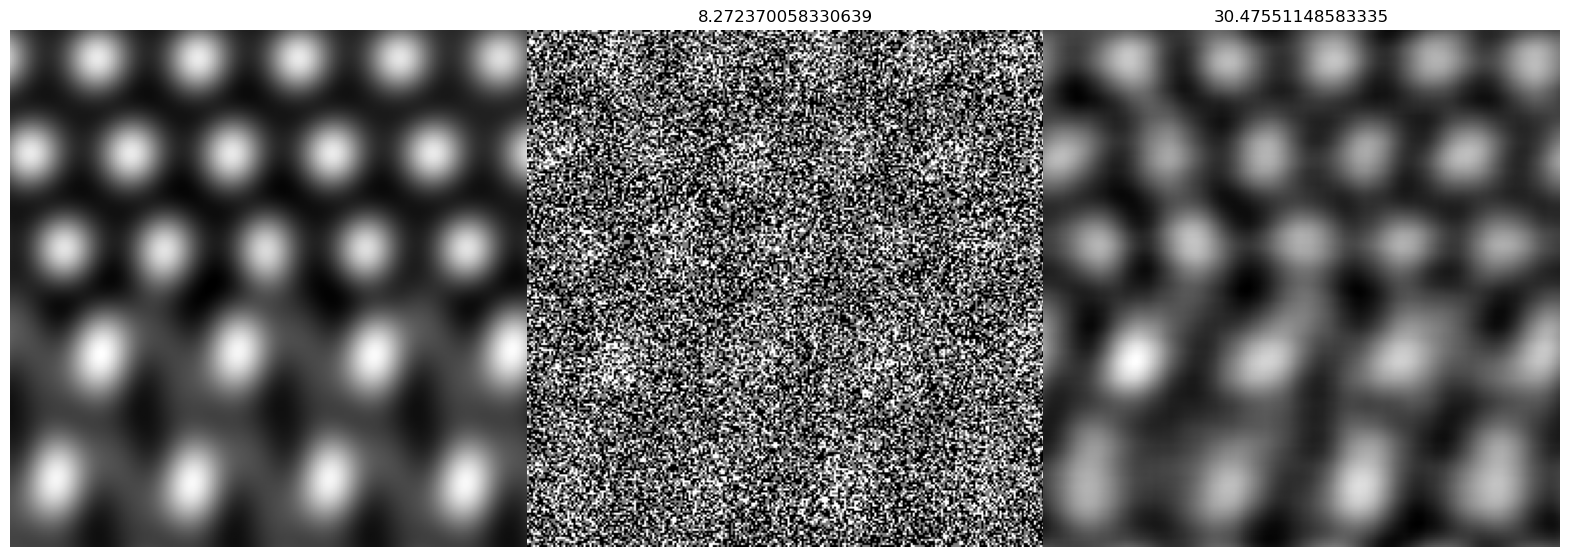

In [ ]:
import numpy as np
from PIL import Image
import torch
# path = '/Users/liukangning/Downloads/Denoising_Tutorial/electron-microscopy-denoising/images/clean-images-for-paper/PtNp2-S1-2_2-S3_1_240slc_1024x1024_6nmDefocus.tif'
path = file_root_path + '/electron-microscopy-denoising/images/clean-images-for-paper/PtNp2-S1-2_2-S3_1_240slc_1024x1024_6nmDefocus.tif'
# image_np = np.array(Image.open(path).resize((256,256)))
image_np = np.array(Image.open(path))
image_np = center_crop(image_np, output_size=(256,256))



image_tensor = torch.tensor(image_np).unsqueeze(0)
clean_tmpt = image_tensor.unsqueeze(0)

# for noise_std in noise_std_array:
#     print('='*50 +'\n\n')
#     print('Noise Std: ', noise_std)

visualize_best_wiener_denoising(image_tensor, wiener_star, fft_sample=(image_np.shape[0], image_np.shape[1]), noise_scale=noise_scale)

In [ ]:
def get_noise(data, noise_std = 0.1, mode='poisson', max_noise = 5e-1, noise_scale=1):
    if mode=='poisson':
        source = data
        scaled_source = source * noise_scale
        # Generate Poisson noise sample based on the scaled source
        noise_sample = Poisson(scaled_source).sample()
        # Scale back the generated noise
        noise_sample = (noise_sample - scaled_source) / noise_scale
        noise = noise_sample
    else:
        noise = get_noise_others(data, noise_std, mode, max_noise)
    return noise

def get_noise_others(data, noise_std = 0.1, mode='S', max_noise = 5e-1):
    noise = torch.randn_like(data);
    if mode == 'B':
        n = noise.shape[0];
        noise_tensor_array = max_noise * torch.rand(n);
        for i in range(n):
            noise.data[i] = noise.data[i] * noise_tensor_array[i];
    else:
        noise.data = noise.data * noise_std;
    return noise

In [ ]:
def validation_error_psnr(model, dataset_val, add_noise = False, noise_mode = 'poisson', noise_std=0.1, max_noise = 5e-1, noise_scale=1):
    model.eval()
    error_val = 0;
    psnr_val = 0;
    total_length = 0;

    criterion = nn.MSELoss(reduction = 'sum');

    for data in dataset_val:
        data = data['image']
#         data = data.resize((256,256))
        target = data.clone()

        if add_noise:

            data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

        data = data.to(device)
        target = target.to(device)
        out_val = model( data );

        error_val += criterion(out_val, target).item()
        psnr_val += ( batch_PSNR(out_val, target, 1.0) * data.shape[0] )
        total_length += data.shape[0];

    return error_val/total_length, psnr_val/total_length

# Neural network Training: U-Net

It is recommended to skip this process if GPU is not avaible, please load the provided pretrained model

## Setting the device (GPU or CPU)

In [ ]:
USE_CUDA = True
device = torch.device("cuda") if (
        torch.cuda.is_available() and USE_CUDA) else torch.device("cpu")

## Supervised training: Training with Continuous Noise Sampling or Not

In [ ]:
sys.path.append(file_root_path + '/electron-microscopy-denoising')
sys.path.append(file_root_path + '/electron-microscopy-denoising/models_microscopy')

import models_microscopy

In [ ]:
diff_checkpoint_path = {
    'White-4-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-small.pt',
    # 'White-6-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-big.pt',
}

In [ ]:
dataset = 'ptceo2'
contrast = 'white'
# data_path = '/scratch/sm7582/prince/sm7582/datasets/Nanoparticles/ptceo2-1024'
data_path = file_root_path + '/electron-microscopy-denoising/images'
batch_size = 1




In [ ]:
def load_model(checkpoint_path):
    state_dict = torch.load( checkpoint_path, map_location=lambda s,
                                l: default_restore_location(s,"cpu"))

    args = argparse.Namespace(
        **{**vars(state_dict["args"])})
    model = models_microscopy.build_model(args).to(device)
    model.load_state_dict(state_dict["model"][0])
    model.eval()
    return model

In [ ]:
def load_model_fromscratch(checkpoint_path):
    state_dict = torch.load( checkpoint_path, map_location=lambda s,
                                l: default_restore_location(s,"cpu"), weights_only=False)

    args = argparse.Namespace(
        **{**vars(state_dict["args"])})
    model = models_microscopy.build_model(args).to(device)
#     model.load_state_dict(state_dict["model"][0])
#     model.eval()
    return model

In [ ]:
net_dict = {}
for key, checkpoint_path in diff_checkpoint_path.items():
    net_dict[key] = load_model_fromscratch(checkpoint_path).to(device)
    print(f" {key} with parameters {sum(p.numel() for p in net_dict[key].parameters()):,}")

 White-4-128 with parameters 5,613,441


In [ ]:
def validation_error_psnr(model, dataset_val, add_noise = False, noise_mode = 'poisson', noise_std=0.1, max_noise = 5e-1, noise_scale=1):
    model.eval()
    error_val = 0;
    psnr_val = 0;
    total_length = 0;

    criterion = nn.MSELoss(reduction = 'mean');

    for data in dataset_val:
        data = data['image']
#         data = data.resize((256,256))
        target = data.clone()

        if add_noise:
#
            data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

        data = data.to(device)
        target = target.to(device)
        out_val = model( data );

        error_val += criterion(out_val, target).item()
        psnr_val += ( batch_PSNR(out_val, target, 1.0) * data.shape[0] )
        total_length += data.shape[0];

    return error_val/total_length, psnr_val/total_length

In [ ]:
def train_network_on_noise_supervised(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=1):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;

    for epoch in range(max_epoch):

#         if epoch > milestone:
#             for param_group in optimizer.param_groups:
#                 param_group["lr"] = lr/10;

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
            data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data += get_noise(data, mode = noise_mode, max_noise = max_noise, noise_scale=noise_scale);
#                 target += get_noise(data, mode = noise_mode, max_noise = max_noise, noise_scale=noise_scale);
            data = data.to(device)
            target = target.to(device)

#             print(data.shape)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

            del data
            del target

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr, train_loss, val_loss

In [ ]:
def train_network_on_noise_supervised_fixed(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=1):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;

    noise_list = []

    for i, data in enumerate(train_loader):

        noise_list.append(get_noise(data['image'], mode = noise_mode, max_noise = max_noise, noise_scale=noise_scale))




    for epoch in range(max_epoch):

        if epoch > milestone:
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr/10

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
            data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data += noise_list[i]
            data = data.to(device)
            target = target.to(device)



#             print(data.shape)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

            del data
            del target

#             if num_batch is not None:
#                 if i==num_batch:
#                     break

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr, train_loss, val_loss

In [ ]:
train_loader, val_loader, test_loader = data.build_dataset(dataset, data_path, batch_size=20,
                                           test_batch_size=batch_size, rotation_aug = False, resize_aug=False,
                                           contrast = contrast, num_workers=0,image_size=256)




In [ ]:
from torch.utils.data import DataLoader, Subset
import numpy as np

def get_subset(train_loader, portion=0.1):
    indices = np.arange(len(train_loader.dataset))  # Create an array of indices
    # np.random.shuffle(indices)  # Shuffle the indices

    # Choose a specific number of samples for training
    num_train_samples = int(portion * len(train_loader.dataset))  # For example, 80% of the dataset
    print(num_train_samples)
    train_indices = indices[:num_train_samples]

    train_subset = Subset(train_loader.dataset, train_indices)
    train_loader_subset = DataLoader(train_subset, batch_size=4, shuffle=True)
    return train_loader_subset


In [ ]:
train_loader_subset = get_subset(train_loader)

35


In [ ]:


small_checkpoint_path = {
    'White-4-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-small.pt',
}



net_dict = {}
for key, checkpoint_path in small_checkpoint_path.items():
    net_supervised_continous = load_model_fromscratch(checkpoint_path).to(device)
    net_supervised_fixed_noise = load_model_fromscratch(checkpoint_path).to(device)
#     print(f" {key} with parameters {sum(p.numel() for p in net_dict[key].parameters()):,}")

### Continuous or Not: Small training set

1 train error:  0.06170612190450941 val error:  0.23669220271863436 train psnr:  6.199377417971387 val psnr:  6.258764692704536
2 train error:  0.0479238178048815 val error:  0.1843968025947872 train psnr:  7.297148160233084 val psnr:  7.34367888035055
3 train error:  0.027704814502171108 val error:  0.10604787657135412 train psnr:  9.685593255790833 val psnr:  9.748223296790966
4 train error:  0.017288328068596977 val error:  0.09968812136273635 train psnr:  12.532271503051062 val psnr:  11.213545141171931
5 train error:  0.0063908722783838 val error:  0.03677708292870145 train psnr:  16.415857031138703 val psnr:  15.092076124063794
6 train error:  0.0028372881135770253 val error:  0.012206992379536754 train psnr:  19.73698491664645 val psnr:  19.334635019692257
7 train error:  0.002382508771760123 val error:  0.010298578656817737 train psnr:  20.50890025524605 val psnr:  20.068174107551044
8 train error:  0.0018598622110273157 val error:  0.008299270399699086 train psnr:  21.52613864

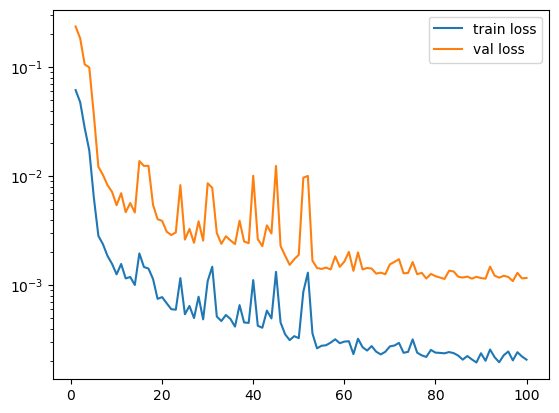

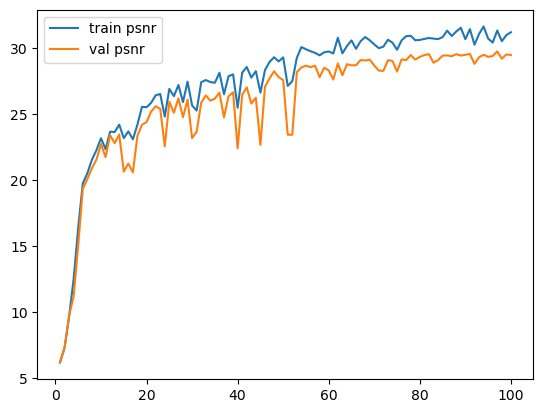

In [ ]:


net_supervised_continous, train_psnr_continous, val_psnr_continous, train_loss_continous, val_loss_continous = train_network_on_noise_supervised(net_supervised_continous, train_loader_subset, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 50,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)


1 train error:  0.049024784564971925 val error:  0.18810957748638957 train psnr:  7.197305555133021 val psnr:  7.2568604018359855


2 train error:  0.031186026973383768 val error:  0.11980214244440983 train psnr:  9.16483201150364 val psnr:  9.219101540409875
3 train error:  0.01575572852577482 val error:  0.06059241549749123 train psnr:  12.131558433549179 val psnr:  12.184900591125215
4 train error:  0.008316742203065327 val error:  0.03288643111131693 train psnr:  14.910529563924307 val psnr:  14.844332214998866
5 train error:  0.003084172122180462 val error:  0.012705896000720952 train psnr:  19.23177507191622 val psnr:  18.99493818623942
6 train error:  0.0022225945788834777 val error:  0.009203112635173295 train psnr:  20.715904092457148 val psnr:  20.42827996439029
7 train error:  0.001626549381762743 val error:  0.007519421731366923 train psnr:  22.105207665466857 val psnr:  21.38929577758957
8 train error:  0.0014954752288758755 val error:  0.006662133885057349 train psnr:  22.440951048551167 val psnr:  21.90609937319855
9 train error:  0.0012905426057321684 val error:  0.00595308620923836 train psnr:  23.

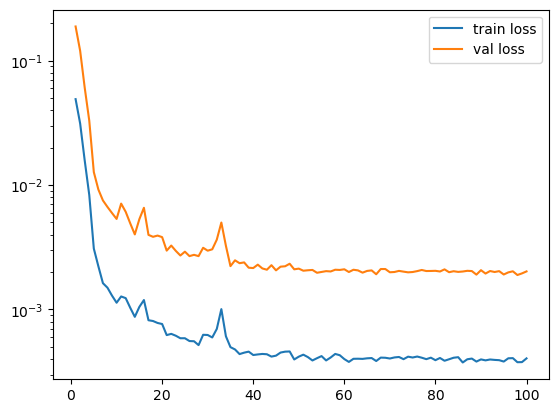

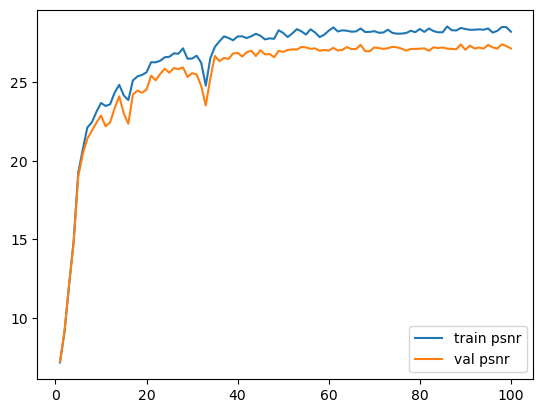

In [ ]:


net_supervised_fixed_noise, train_psnr_fixed_noise, val_psnr_fixed_noise, train_loss_fixed_noise, val_loss_fixed_noise= train_network_on_noise_supervised_fixed(net_supervised_fixed_noise, train_loader_subset, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 50,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)


In [ ]:
def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


def plot_combined_losses(train_loss, val_loss, train_loss_dnn, val_loss_dnn, save_path='combined_losses.pdf', title1='DNN without Batch Normalization', title2='DNN with Batch Normalization', title='Combined Losses', y_max=0.2, smooth=False, xlim=100, figsize=(8,8), tick_font_size=14, ylabel='MSE'):
    y_min = 0
    y_max = y_max
    fig, ax = plt.subplots(figsize=figsize)

    if smooth:
        # Apply moving average if smoothing is desired
        train_loss = moving_average(train_loss)
        val_loss = moving_average(val_loss)
        train_loss_dnn = moving_average(train_loss_dnn)
        val_loss_dnn = moving_average(val_loss_dnn)

    # Plotting for the first experiment
    ax.plot(train_loss, label=title1 + ': Train ' + ylabel, color='blue')
    ax.plot(val_loss, label=title1 + ': Validation ' + ylabel, color='blue', linestyle='-.')
    # ax.axhline(y=wiener_star_loss, color='red', linestyle='--', label='Wiener Star Loss')

    # Plotting for the DNN experiment
    ax.plot(train_loss_dnn, label=title2 + ': Train ' + ylabel, color='green')
    ax.plot(val_loss_dnn, label=title2 + ': Validation ' + ylabel, color='green', linestyle='-.')

    # ax.set_title(title, fontsize=16)
    ax.set_xlabel('Epoch', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.legend(fontsize=16)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=2)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0, xlim)

    ax.tick_params(axis='both', which='major', labelsize=tick_font_size)


    plt.tight_layout()
    save_path = title1 + title2 + '.png'
    plt.savefig(save_path, dpi=300)
    plt.show()


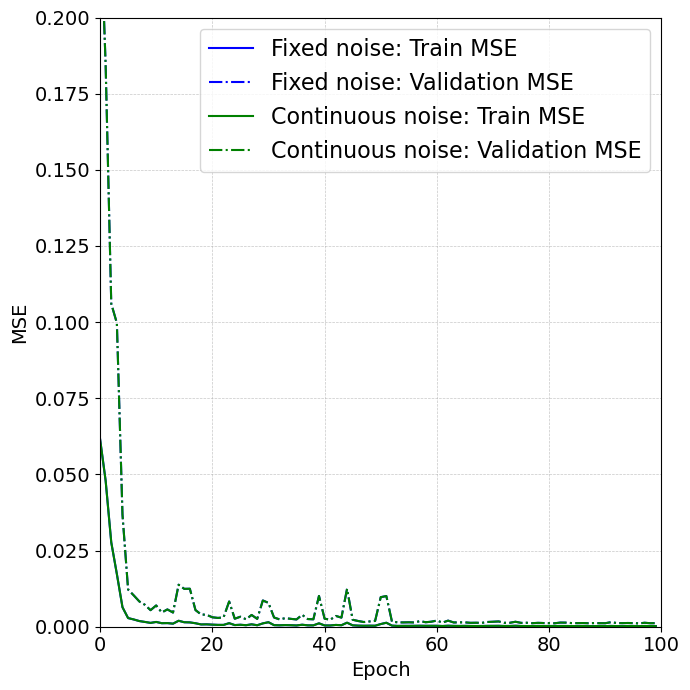

In [ ]:
plot_combined_losses(  train_loss_continous, val_loss_continous, train_loss_continous, val_loss_continous, title1='Fixed noise', title2='Continuous noise', y_max=0.2, smooth=False, xlim=100, figsize=(7,7))

### Continuous or Not: Large training set

In [ ]:
# net_supervised_continous = net_dict['White-4-128'].copy()
# net_supervised_fixed_noise = net_dict['White-4-128'].copy()


small_checkpoint_path = {
    'White-4-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-small.pt',
}



# net_dict = {}
for key, checkpoint_path in small_checkpoint_path.items():
    net_supervised_continous_large = load_model_fromscratch(checkpoint_path).to(device)
    net_supervised_fixed_noise_large = load_model_fromscratch(checkpoint_path).to(device)
#     print(f" {key} with parameters {sum(p.numel() for p in net_dict[key].parameters()):,}")

In [ ]:
train_loader_subset_large = get_subset(train_loader,1)

353


1 train error:  0.0009201020807048923 val error:  0.003982559495948647 train psnr:  24.417083820441498 val psnr:  24.055991721136166
2 train error:  0.0004930175714215881 val error:  0.002305495822312016 train psnr:  27.222397047158744 val psnr:  26.480864590676738
3 train error:  0.0003658684391710411 val error:  0.0019234332476595515 train psnr:  28.814902093742038 val psnr:  27.515349576142142
4 train error:  0.0002690253829749739 val error:  0.001410456852203137 train psnr:  29.990866647421008 val psnr:  28.70540256380617
5 train error:  0.00023226474151912305 val error:  0.0012437129166516427 train psnr:  30.601178278447126 val psnr:  29.20568240903924
6 train error:  0.00031078881887513246 val error:  0.0016834572705097105 train psnr:  30.08901378408644 val psnr:  28.3963725206941
7 train error:  0.00020850758367051863 val error:  0.0010218119775680335 train psnr:  31.015588858985254 val psnr:  30.08066818621659
8 train error:  0.00020758882323253594 val error:  0.001151950141464

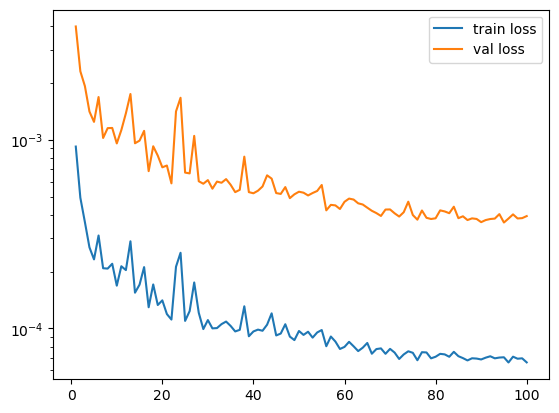

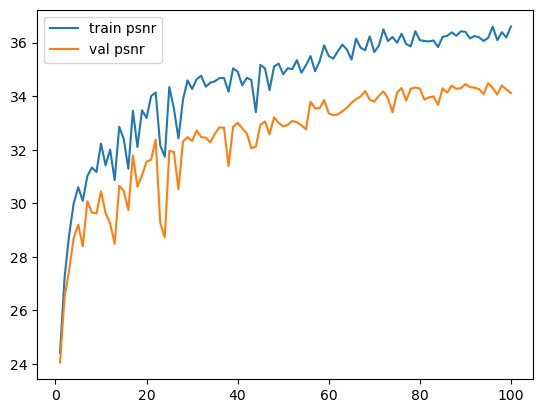

In [ ]:


net_supervised_continous_large, train_psnr_continous_large, val_psnr_continous_large, train_loss_continous_large, val_loss_continous_large = train_network_on_noise_supervised(net_supervised_continous_large, train_loader_subset_large, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 50,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)

net_dict_filename = 'microscopy_supervised_continous.pth'
torch.save(net_supervised_continous_large.cpu().state_dict(),  os.path.join(path_to_saved_models, net_dict_filename))


In [ ]:
torch.save(net_supervised_continous_large.cpu().state_dict(),  os.path.join(path_to_saved_models, net_dict_filename))

1 train error:  0.0053167344432419154 val error:  0.03316309658418361 train psnr:  18.99502676428486 val psnr:  16.655367192252942
2 train error:  0.0011245002020308721 val error:  0.005317136743351033 train psnr:  23.806512441006173 val psnr:  23.08854160112819
3 train error:  0.001515380678719527 val error:  0.00911444646159285 train psnr:  23.393968111523947 val psnr:  21.824967892935113
4 train error:  0.000644481222794283 val error:  0.003228680022354973 train psnr:  26.161292734406363 val psnr:  25.219781065617525
5 train error:  0.0005538696123065464 val error:  0.0028873717804488385 train psnr:  26.92195239547528 val psnr:  25.71965331045052
6 train error:  0.0005551655763607187 val error:  0.0026516670692025832 train psnr:  27.38664347215606 val psnr:  26.232314149047365
7 train error:  0.00043902516717265333 val error:  0.0024454213409243445 train psnr:  27.90740745286712 val psnr:  26.367762274848584
8 train error:  0.0004389869229255967 val error:  0.0023468554626513076 tra

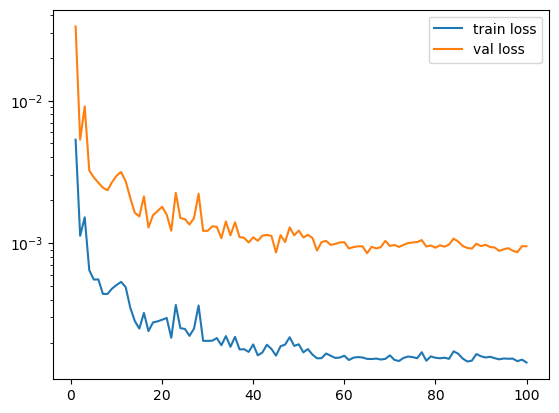

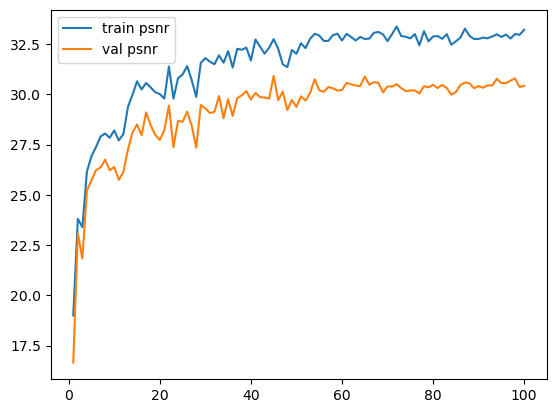

In [ ]:


net_supervised_fixed_noise_large, train_psnr_fixed_noise_large, val_psnr_fixed_noise_large, train_loss_fixed_noise_large, val_loss_fixed_noise_large = train_network_on_noise_supervised_fixed(net_supervised_fixed_noise_large, train_loader_subset_large, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 50,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)


net_dict_filename = 'microscopy_supervised_fixed_noise.pth'
torch.save(net_supervised_fixed_noise_large.cpu().state_dict(),  os.path.join(path_to_saved_models, net_dict_filename))


### DNCNN

In [ ]:
def load_model_from_scratch_dncnn(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location=lambda s, l: default_restore_location(s, "cpu"),weights_only=False)
    args = argparse.Namespace(**{ **vars(state_dict["args"]), "no_log": True})
    print(args)

    model = models.build_model(args).to(device)
#     model.load_state_dict(state_dict["model"][0])
#     model.eval()
    return model

In [ ]:

model = 'dncnn'
l = 0   # lower bound of training range
h = 100 # upper bound of training range
pretrained_base = file_root_path + '/pretrained_models/Natural_images'
net_supervised_continous_large_dncnn = load_model_from_scratch_dncnn(os.path.join(pretrained_base, model, str(l)+'-'+str(h)+'.pt'))

Namespace(data_path='../data/', dataset='bsd400', batch_size=128, model='dncnn', noise_mode='B', noise_std=25, min_noise=100, max_noise=0, lr=0.001, num_epochs=70, valid_interval=1, save_interval=1, seed=0, output_dir='experiments', experiment=None, resume_training=False, restore_file=None, no_save=False, step_checkpoints=False, no_log=True, log_interval=100, no_visual=False, visual_interval=100, no_progress=False, draft=False, dry_run=False, in_channels=1, hidden_size=64, num_layers=20, bias=False, experiment_dir=None, checkpoint_dir=None, log_dir=None, log_file=None)


1 train error:  0.08529459788508861 val error:  0.3328321450635007 train psnr:  4.7070001792592135 val psnr:  4.778217491939157
2 train error:  0.01757498849552684 val error:  0.06900186091661453 train psnr:  11.568026856244682 val psnr:  11.611551495366877
3 train error:  0.006558052541176253 val error:  0.02608855382392281 train psnr:  15.850293063994599 val psnr:  15.836924706333566
4 train error:  0.002168819197472027 val error:  0.008737340128343356 train psnr:  20.65797572075357 val psnr:  20.58871428109883
5 train error:  0.001590553181715542 val error:  0.0065681695398923596 train psnr:  22.015409963058808 val psnr:  21.839977446939848
6 train error:  0.0007158514631980708 val error:  0.0030833077616989613 train psnr:  25.49104967917759 val psnr:  25.14267647783919
7 train error:  0.0017493586557212868 val error:  0.0071968092141967074 train psnr:  21.5938532265952 val psnr:  21.437264920495945
8 train error:  0.0005638606832481435 val error:  0.0024742636290427888 train psnr: 

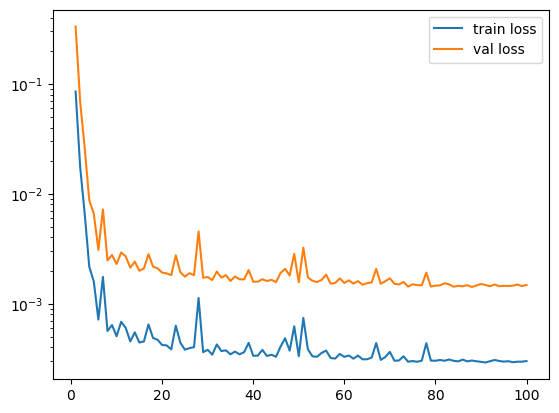

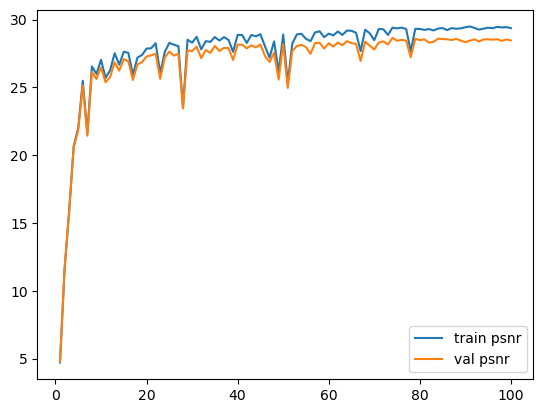

In [ ]:


net_supervised_continous_large_dncnn, train_psnr_continous_large_dncnn, val_psnr_continous_large_dncnn, train_loss_continous_large_dncnn, val_loss_continous_large_dncnn = train_network_on_noise_supervised(net_supervised_continous_large_dncnn, train_loader_subset_large, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 50,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)

net_dict_filename = 'microscopy_supervised_continous_dncnn.pth'
torch.save(net_supervised_continous_large_dncnn.cpu().state_dict(),  os.path.join(path_to_saved_models, net_dict_filename))


In [ ]:
# plot_combined_losses(  train_loss_fixed_noise_large, val_loss_fixed_noise_large, train_loss_continous_large, val_loss_continous_large, title1='Fixed noise', title2='Continuous noise', y_max=100, smooth=False, xlim=100, figsize=(7,7))

In [ ]:
# plot_combined_losses(  train_psnr_fixed_noise_large, val_psnr_fixed_noise_large, train_psnr_continous_large, val_psnr_continous_large, title1='Fixed noise', title2='Continuous noise', y_max=40, smooth=False, xlim=100, figsize=(7,7),ylabel='PSNR')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def plot_validation_losses_seaborn(val_loss, val_loss_dnn, title1='DNN without Batch Normalization',
                                   title2='DNN with Batch Normalization', title='Validation Losses Comparison',
                                   y_max=0.2, smooth=False, xlim=100, figsize=(8,8), tick_font_size=14, ylabel='MSE',
                                  legend_font_size=16):

    # Apply moving average if smoothing is desired
    if smooth:
        val_loss = moving_average(val_loss)
        val_loss_dnn = moving_average(val_loss_dnn)

    # Create a DataFrame for Seaborn plotting
    epochs = range(1, len(val_loss) + 1)
    df = pd.DataFrame({
        'Epoch': np.concatenate((epochs, epochs)),
        'Loss': np.concatenate((val_loss, val_loss_dnn)),
        'Model': np.concatenate((([title1] * len(val_loss)), ([title2] * len(val_loss_dnn))))
    })

    # Plotting using Seaborn
    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x='Epoch', y='Loss', hue='Model', palette=['blue', 'red'], linewidth=2.5)

#     plt.title(title)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.ylim(0, y_max)
    plt.xlim(0, xlim)
    plt.tick_params(axis='both', which='major', labelsize=tick_font_size)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.grid(False)
    plt.legend(fontsize=legend_font_size)
    plt.tight_layout()

    save_path = ylabel + title1 + '_' + title2 + 'microscopy_validation.png'
    plt.savefig(save_path, dpi=300)
    plt.show()


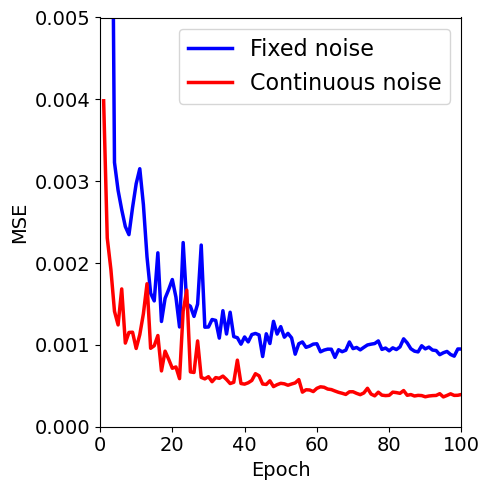

In [ ]:
plot_validation_losses_seaborn(  val_loss_fixed_noise_large, val_loss_continous_large, title1='Fixed noise', title2='Continuous noise', y_max=0.005, smooth=False, xlim=100, figsize=(5,5),ylabel='MSE')

## Unsupervised training: Noise2Noise

In [ ]:
def train_network_on_noise2noise(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=1):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;

    for epoch in range(max_epoch):

#         if epoch > milestone:
#             for param_group in optimizer.param_groups:
#                 param_group["lr"] = lr/10;

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
            data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data += get_noise(data, mode = noise_mode, max_noise = max_noise, noise_scale=noise_scale);
                target += get_noise(data, mode = noise_mode, max_noise = max_noise, noise_scale=noise_scale);
            data = data.to(device)
            target = target.to(device)

#             print(data.shape)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

            del data
            del target

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr

In [ ]:
# net_supervised_continous = net_dict['White-4-128'].copy()
# net_supervised_fixed_noise = net_dict['White-4-128'].copy()


small_checkpoint_path = {
    'White-4-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-small.pt',
}



# net_dict = {}
for key, checkpoint_path in small_checkpoint_path.items():
    net_noise2noise = load_model_fromscratch(checkpoint_path).to(device)
#     print(f" {key} with parameters {sum(p.numel() for p in net_dict[key].parameters()):,}")

5 train error:  0.00015758365200088483 val error:  0.0036242228540542877 train psnr:  25.18852752073626 val psnr:  24.547893640290486
10 train error:  0.0001357454541416327 val error:  0.004766896103606804 train psnr:  26.737563062917445 val psnr:  24.488709265923095
15 train error:  7.788943147904137e-05 val error:  0.0022883897457320833 train psnr:  28.784236615173615 val psnr:  27.145382508348323
20 train error:  5.4854988357943956e-05 val error:  0.0016015774178269662 train psnr:  30.209747689902922 val psnr:  28.581753060609525
25 train error:  3.9948753203943413e-05 val error:  0.0010412881077316246 train psnr:  31.34979710928344 val psnr:  29.956000036786733
30 train error:  4.9166375917590964e-05 val error:  0.0016048443779398344 train psnr:  31.066510551192902 val psnr:  29.03597827758798
35 train error:  4.031936154587368e-05 val error:  0.001150595416363917 train psnr:  31.545900710592946 val psnr:  29.79091342842081
40 train error:  3.115013841982857e-05 val error:  0.00083

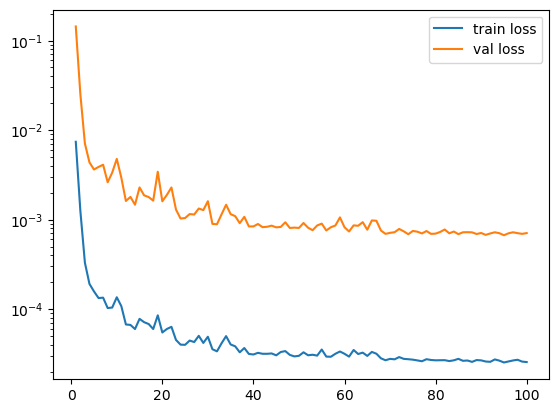

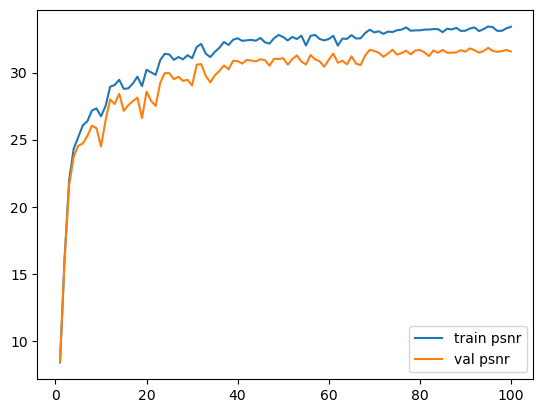

In [ ]:
net_temp = net_noise2noise

net_temp, train_psnr_tmpt, val_psnr_tmpt = train_network_on_noise2noise(net_temp, train_loader, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 100,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 5,
                        plot_loss = True)
#             visualize_filters(net_temp)


In [ ]:
net_dict_filename = 'microscopy_noise2noise2.pth'
torch.save(net_temp.cpu().state_dict(),  os.path.join(path_to_saved_models, net_dict_filename))